# California Housing: EDA + Regression

This notebook demonstrates a compact end-to-end regression workflow on the **California Housing** dataset from scikit-learn.

## Goals
- Load and inspect the dataset
- Perform basic exploratory data analysis (EDA)
- Build regression baselines
- Train and evaluate linear regression models
- Interpret coefficients and residuals
- Compare with a stronger non-linear benchmark


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)


## 2. Load the dataset

According to the scikit-learn documentation, this dataset contains:
- **20,640 samples**
- **8 numerical input features**
- A continuous target: **median house value**


In [2]:
try:
    housing = fetch_california_housing(as_frame=True)
except Exception as e:
    raise RuntimeError(
        "Could not download/load the California Housing dataset. "
        "This dataset is fetched from the internet the first time. "
        "Please ensure network access is available, then rerun this cell."
    ) from e

df = housing.frame.copy()

print("Feature names:", housing.feature_names)
print("Target name:", housing.target_names)
print("Shape:", df.shape)
df.head()


Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target name: ['MedHouseVal']
Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<Axes: >

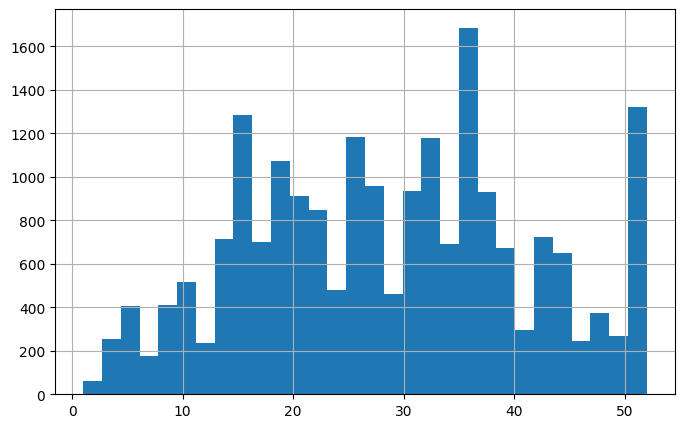

In [59]:
df['HouseAge'].hist(bins=30)

In [3]:
for linw in housing.DESCR.split("\n\n"):
    print(linw)

.. _california_housing_dataset:
California Housing dataset
--------------------------
**Data Set Characteristics:**
:Number of Instances: 20640
:Number of Attributes: 8 numeric, predictive attributes and the target
:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude
:Missing Attribute Values: None
This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html
The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).
This dataset was derived from the 1990 U.S. census, using one row per census
bloc

### Dataset schema

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


### Summary statistics

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


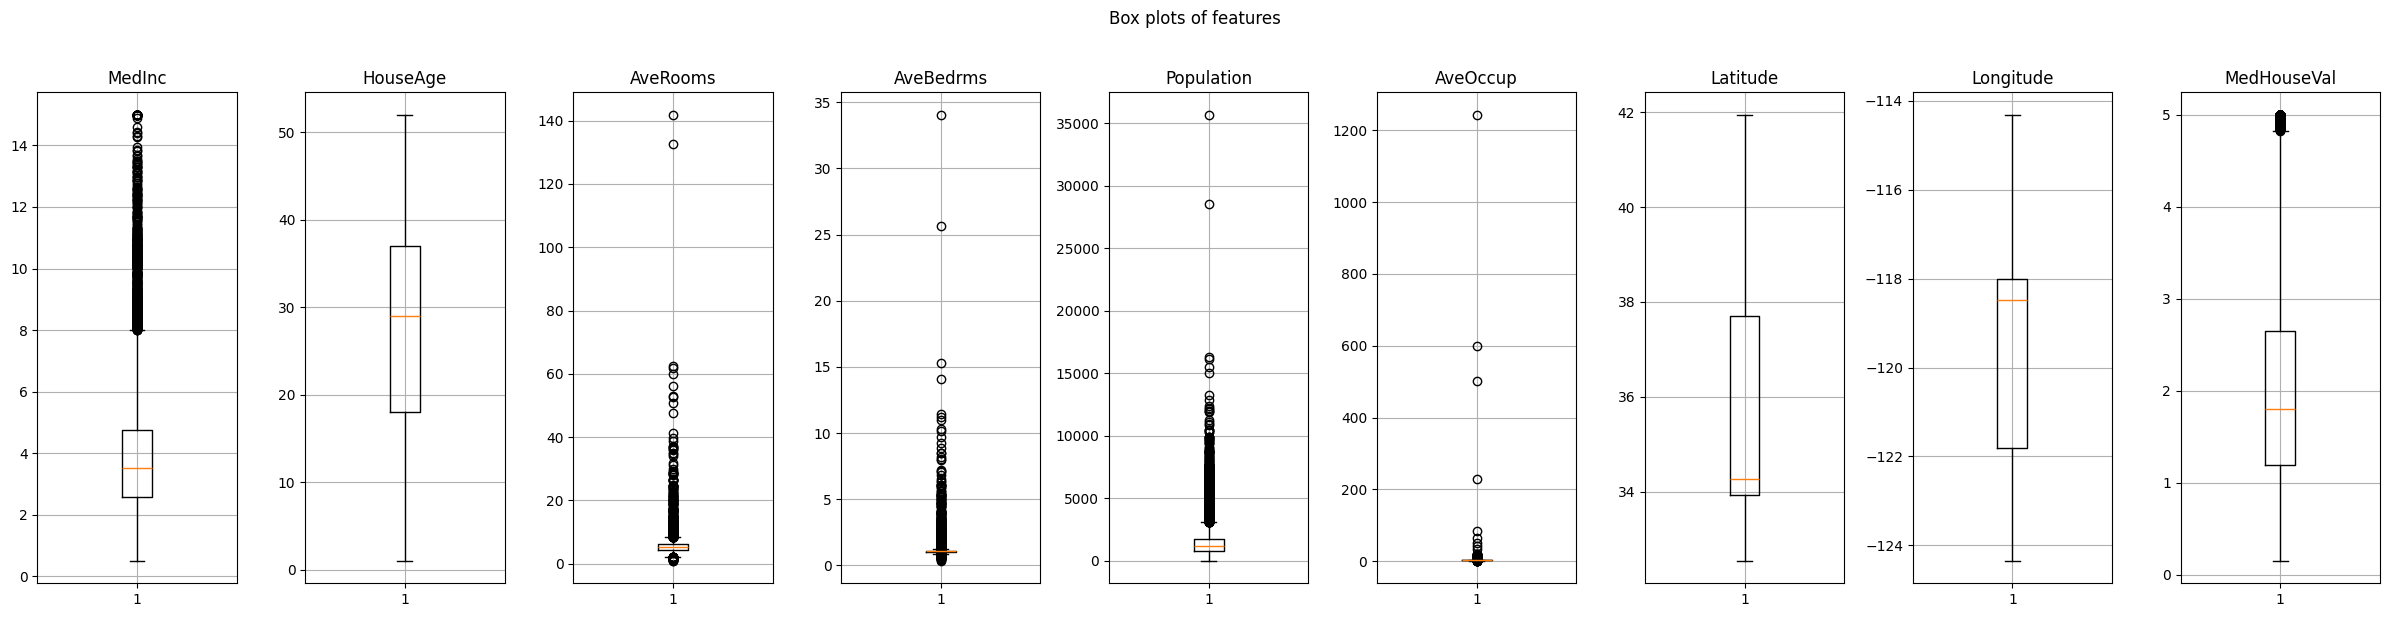

In [56]:
# box plots of all the features
fig, axes = plt.subplots(1, 9, figsize=(24, 6)) 
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col)
plt.suptitle("Box plots of features", y=1.02)
plt.tight_layout()  
plt.show()


## 3. Missing values check

In [6]:
df.isna().sum().sort_values(ascending=False)

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

## 4. Feature descriptions

- **MedInc**: median income in block group
- **HouseAge**: median house age
- **AveRooms**: average rooms per household
- **AveBedrms**: average bedrooms per household
- **Population**: block group population
- **AveOccup**: average occupancy
- **Latitude / Longitude**: geographic coordinates
- **MedHouseVal**: target, median house value (in units of 100,000 USD)


## 5. Target distribution

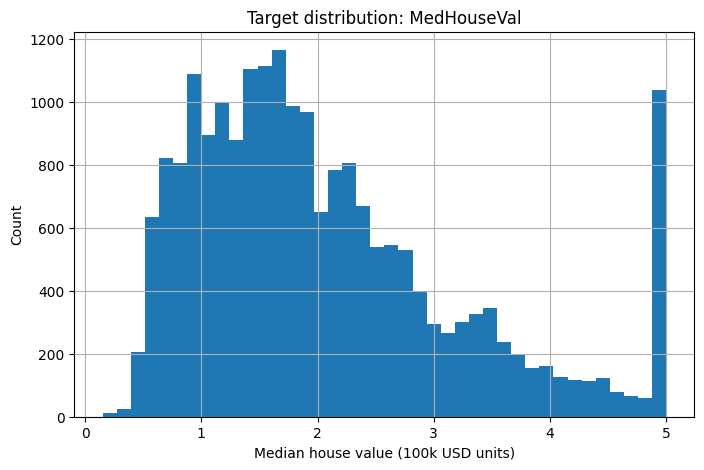

Target min: 0.14999
Target max: 5.00001
Target mean: 2.069


In [7]:
fig, ax = plt.subplots()
ax.hist(df["MedHouseVal"], bins=40)
ax.set_title("Target distribution: MedHouseVal")
ax.set_xlabel("Median house value (100k USD units)")
ax.set_ylabel("Count")
plt.show()

print("Target min:", df["MedHouseVal"].min())
print("Target max:", df["MedHouseVal"].max())
print("Target mean:", df["MedHouseVal"].mean().round(3))


## 6. Univariate EDA

Histograms give a quick view of scale, spread, and skewness.


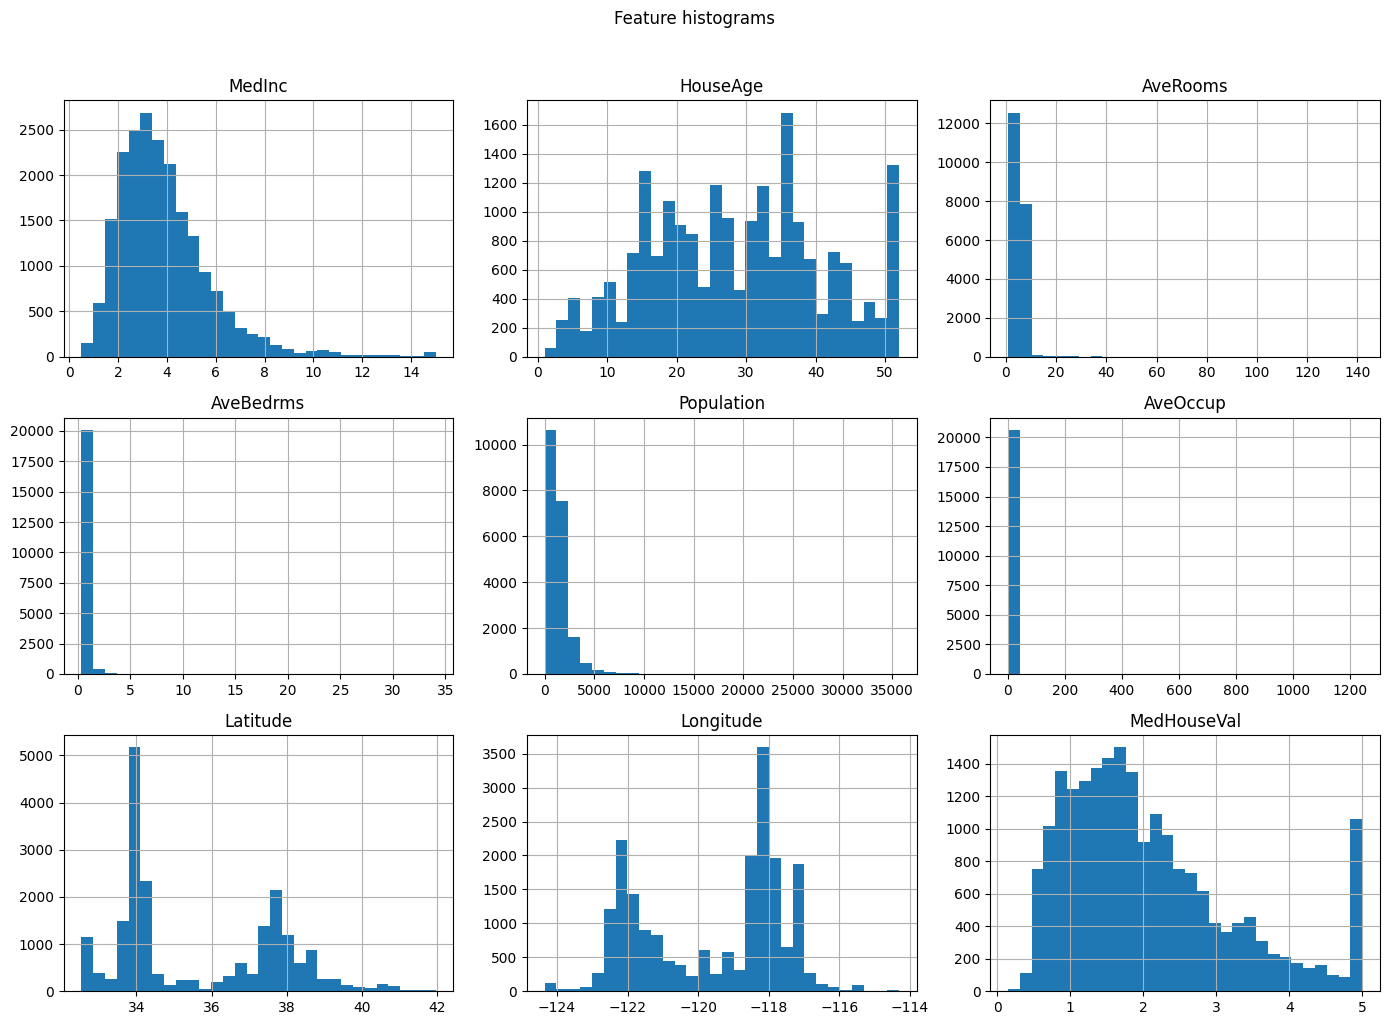

In [8]:
df.hist(figsize=(14, 10), bins=30)
plt.suptitle("Feature histograms", y=1.02)
plt.tight_layout()
plt.show()

## 7. Bivariate EDA

A few plots that are usually informative:
- income vs. target
- location vs. target
- rooms vs. target


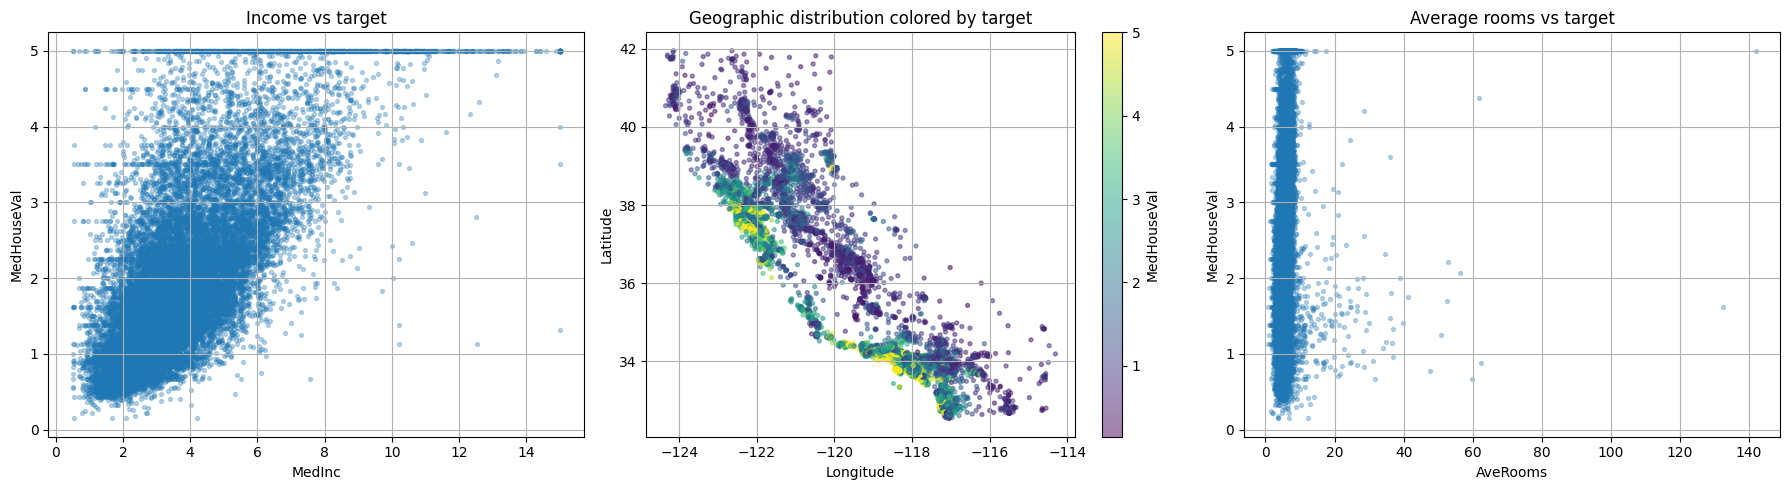

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df["MedInc"], df["MedHouseVal"], s=8, alpha=0.3)
axes[0].set_title("Income vs target")
axes[0].set_xlabel("MedInc")
axes[0].set_ylabel("MedHouseVal")

sc = axes[1].scatter(df["Longitude"], df["Latitude"], c=df["MedHouseVal"], s=8, alpha=0.5)
axes[1].set_title("Geographic distribution colored by target")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
fig.colorbar(sc, ax=axes[1], label="MedHouseVal")

axes[2].scatter(df["AveRooms"], df["MedHouseVal"], s=8, alpha=0.3)
axes[2].set_title("Average rooms vs target")
axes[2].set_xlabel("AveRooms")
axes[2].set_ylabel("MedHouseVal")

plt.tight_layout()
plt.show()

## 8. Correlation matrix

This is a fast way to identify strong linear relationships.


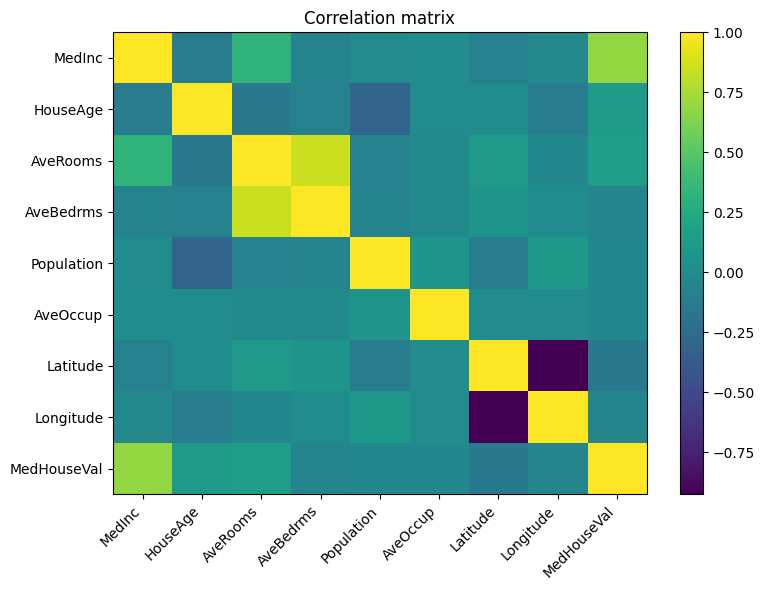

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

In [10]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, interpolation="nearest", aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
ax.set_title("Correlation matrix")
ax.grid(False)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

corr["MedHouseVal"].sort_values(ascending=False)


## 9. Prepare train/test split

In [60]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape: ", X_test.shape, y_test.shape)


Train shape: (16512, 8) (16512,)
Test shape:  (4128, 8) (4128,)


## 10. Evaluation helper

In [61]:
def evaluate_regression(model, X_train, X_test, y_train, y_test, name="model"):
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    results = pd.DataFrame(
        {
            "split": ["train", "test"],
            "MAE": [
                mean_absolute_error(y_train, pred_train),
                mean_absolute_error(y_test, pred_test),
            ],
            "RMSE": [
                np.sqrt(mean_squared_error(y_train, pred_train)),
                np.sqrt(mean_squared_error(y_test, pred_test)),
            ],
            "R2": [
                r2_score(y_train, pred_train),
                r2_score(y_test, pred_test),
            ],
        }
    )
    results.insert(0, "model", name)
    return results, pred_test


## 11. Baseline: predict the mean

A baseline matters. It tells us whether our actual model learns anything useful.


In [62]:
baseline = DummyRegressor(strategy="mean")
baseline_results, baseline_pred = evaluate_regression(
    baseline, X_train, X_test, y_train, y_test, name="Dummy(mean)"
)
baseline_results


,model,split,MAE,RMSE,R2
0,Dummy(mean),train,0.913911,1.156191,0.000000
1,Dummy(mean),test,0.906069,1.144856,-0.000219


## 12. Single-variable linear regression

Start with just **MedInc** to show the simplest regression setup.


In [63]:
# use only one feature
X_train_single = X_train[["MedInc"]]
X_test_single = X_test[["MedInc"]]

# scale
scaler = StandardScaler()
X_train_single_scaled = scaler.fit_transform(X_train_single)
X_test_single_scaled = scaler.transform(X_test_single)

# fit model
model = LinearRegression()
model.fit(X_train_single_scaled, y_train)

# predict
y_train_pred = model.predict(X_train_single_scaled)
y_test_pred = model.predict(X_test_single_scaled)

# results table
single_results = pd.DataFrame([
    {
        "model": "LinearRegression (MedInc only)",
        "split": "train",
        "MAE": mean_absolute_error(y_train, y_train_pred),
        "RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "R2": r2_score(y_train, y_train_pred),
    },
    {
        "model": "LinearRegression (MedInc only)",
        "split": "test",
        "MAE": mean_absolute_error(y_test, y_test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "R2": r2_score(y_test, y_test_pred),
    },
])

single_results


,model,split,MAE,RMSE,R2
0,LinearRegression (MedInc only),train,0.624951,0.836149,0.476993
1,LinearRegression (MedInc only),test,0.629909,0.842090,0.458859


In [14]:
single_feature = ["MedInc"]

linreg_single = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)

single_results, single_pred = evaluate_regression(
    linreg_single,
    X_train[single_feature],
    X_test[single_feature],
    y_train,
    y_test,
    name="LinearRegression (MedInc only)",
)
single_results


,model,split,MAE,RMSE,R2
0,LinearRegression (MedInc only),train,0.624951,0.836149,0.476993
1,LinearRegression (MedInc only),test,0.629909,0.842090,0.458859


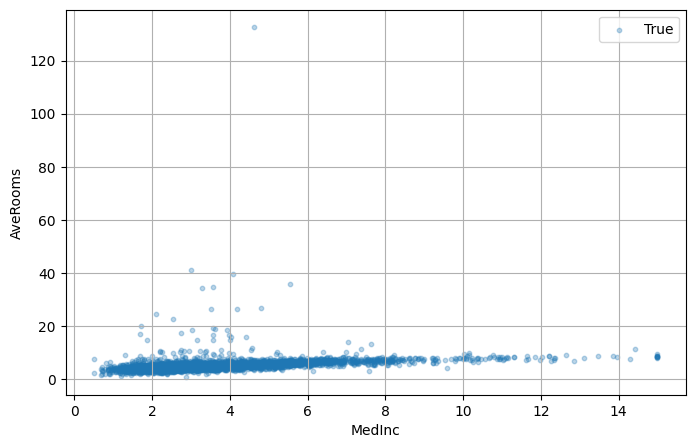

In [24]:
fig, ax = plt.subplots()
ax.scatter(X_test["MedInc"], X_test["AveRooms"], s=10, alpha=0.3, label="True")
# ax.scatter(X_test["MedInc"], single_pred, s=10, alpha=0.3, label="Predicted")
# ax.set_title("Single-feature linear regression")
ax.set_xlabel("MedInc")
ax.set_ylabel("AveRooms")
ax.legend()
plt.show()

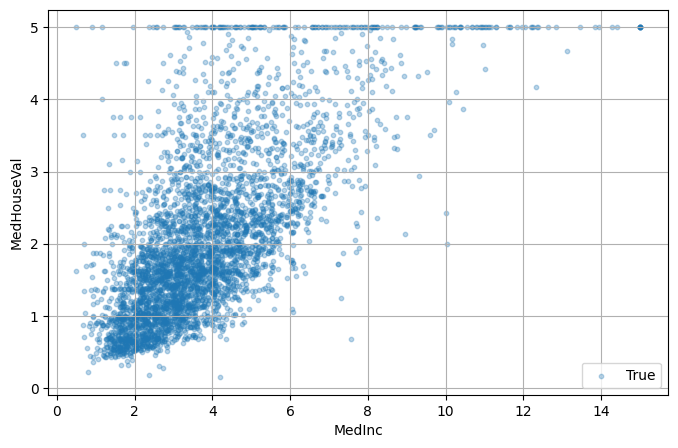

In [18]:
fig, ax = plt.subplots()
ax.scatter(X_test["MedInc"], y_test, s=10, alpha=0.3, label="True")
# ax.scatter(X_test["MedInc"], single_pred, s=10, alpha=0.3, label="Predicted")
# ax.set_title("Single-feature linear regression")
ax.set_xlabel("MedInc")
ax.set_ylabel("MedHouseVal")
ax.legend()
plt.show()

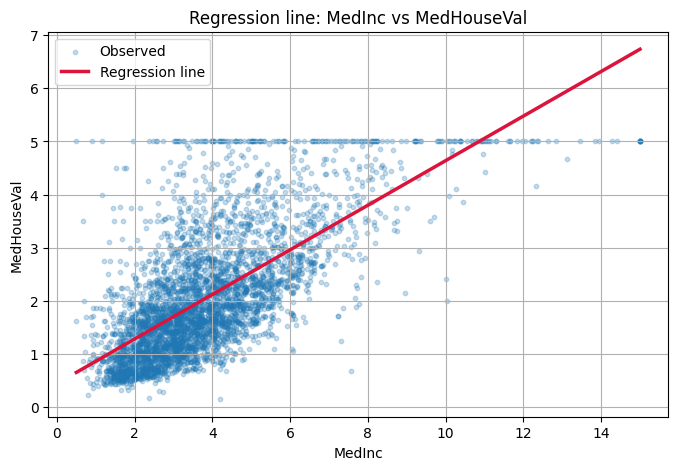

In [16]:
medinc_test = X_test["MedInc"].to_numpy()
order = np.argsort(medinc_test)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(medinc_test, y_test, s=10, alpha=0.25, label="Observed")
ax.plot(medinc_test[order], single_pred[order], color="crimson", linewidth=2.5, label="Regression line")
ax.set_title("Regression line: MedInc vs MedHouseVal")
ax.set_xlabel("MedInc")
ax.set_ylabel("MedHouseVal")
ax.legend()
plt.show()

## 13. Multivariable linear regression

Now use all 8 features.

$$
y = w_1x_1 + w_2 x_2 + ... + w_8 x_8 + b
$$


In [64]:
linreg_all = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)

all_results, all_pred = evaluate_regression(
    linreg_all, X_train, X_test, y_train, y_test, name="LinearRegression (all features)"
)
all_results


,model,split,MAE,RMSE,R2
0,LinearRegression (all features),train,0.528628,0.719676,0.612551
1,LinearRegression (all features),test,0.533200,0.745581,0.575788


### Inspect learned coefficients

Because the inputs are standardized here, coefficient magnitudes are easier to compare.


In [26]:
lin_model = linreg_all.named_steps["model"]
coef_df = pd.DataFrame(
    {
        "feature": X.columns,
        "coefficient": lin_model.coef_,
        "abs_coefficient": np.abs(lin_model.coef_),
    }
).sort_values("abs_coefficient", ascending=False)

coef_df


,feature,coefficient,abs_coefficient
6,Latitude,-0.896929,0.896929
7,Longitude,-0.869842,0.869842
0,MedInc,0.854383,0.854383
3,AveBedrms,0.339259,0.339259
2,AveRooms,-0.294410,0.294410
1,HouseAge,0.122546,0.122546
5,AveOccup,-0.040829,0.040829
4,Population,-0.002308,0.002308


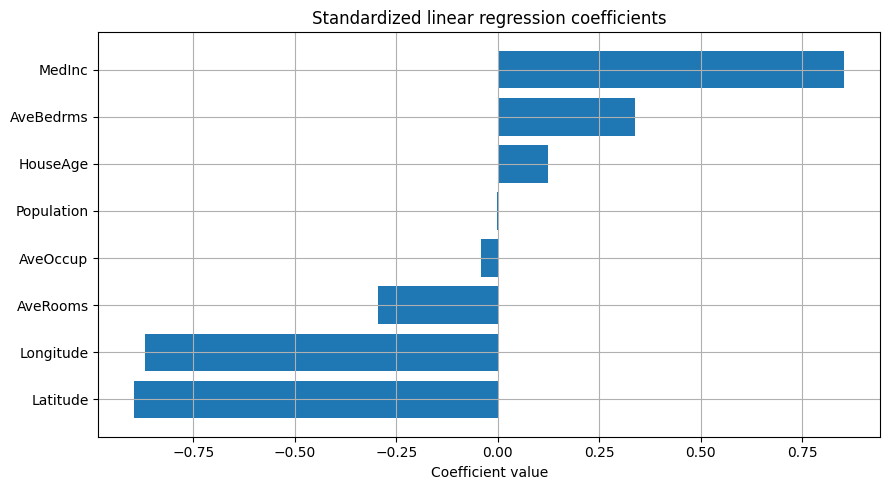

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
coef_df_sorted = coef_df.sort_values("coefficient")
ax.barh(coef_df_sorted["feature"], coef_df_sorted["coefficient"])
ax.set_title("Standardized linear regression coefficients")
ax.set_xlabel("Coefficient value")
plt.tight_layout()
plt.show()


## 14. Raw vs standardized features

A common misconception is that this dataset is already normalized. It is **not**.

- Some features are engineered ratios (`AveRooms`, `AveBedrms`, `AveOccup`)
- `MedInc` is expressed in tens of thousands of dollars
- `Latitude` and `Longitude` are raw coordinates
- `Population` is a raw count and can be highly skewed

In this section we compare:

1. Linear regression on the raw features
2. Linear regression after `StandardScaler`
3. An iterative optimizer (`SGDRegressor`) with and without scaling

Key point: for ordinary least squares, scaling often changes the **coefficients' units** much more than it changes predictive performance.  
For iterative optimization, scaling often helps convergence and stability.

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

# OLS on raw features
linreg_raw = Pipeline([
    ("model", LinearRegression())
])

# OLS on standardized features
linreg_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lr_raw_res, all_pred = evaluate_regression(
    linreg_raw, X_train, X_test, y_train, y_test, name="LinearRegression_raw"
)

lr_scaled_res, all_pred = evaluate_regression(
    linreg_scaled, X_train, X_test, y_train, y_test, name="LinearRegression_scaled"
)

scaling_results = pd.concat(  
    [lr_raw_res, lr_scaled_res],
    ignore_index=True
)
scaling_results


,model,split,MAE,RMSE,R2
0,LinearRegression_raw,train,0.528628,0.719676,0.612551
1,LinearRegression_raw,test,0.533200,0.745581,0.575788
2,LinearRegression_scaled,train,0.528628,0.719676,0.612551
3,LinearRegression_scaled,test,0.533200,0.745581,0.575788


### Compare coefficients before and after standardization

In [40]:
linreg_raw.named_steps["model"].coef_

array([ 4.48674910e-01,  9.72425752e-03, -1.23323343e-01,  7.83144907e-01,
       -2.02962058e-06, -3.52631849e-03, -4.19792487e-01, -4.33708065e-01])

In [41]:
raw_coef = pd.Series(
    linreg_raw.named_steps["model"].coef_,
    index=X.columns,
    name="coefficient_raw_units"
).sort_values(key=np.abs, ascending=False)

scaled_coef = pd.Series(
    linreg_scaled.named_steps["model"].coef_,
    index=X.columns,
    name="coefficient_standardized_units"
).sort_values(key=np.abs, ascending=False)

coef_compare = (
    pd.concat([raw_coef, scaled_coef], axis=1)
    .loc[X.columns]
    .sort_values("coefficient_standardized_units", key=np.abs, ascending=False)
)

coef_compare

,coefficient_raw_units,coefficient_standardized_units
Latitude,-0.419792,-0.896929
Longitude,-0.433708,-0.869842
MedInc,0.448675,0.854383
AveBedrms,0.783145,0.339259
AveRooms,-0.123323,-0.294410
HouseAge,0.009724,0.122546
AveOccup,-0.003526,-0.040829
Population,-0.000002,-0.002308


### Visual comparison of coefficient magnitudes

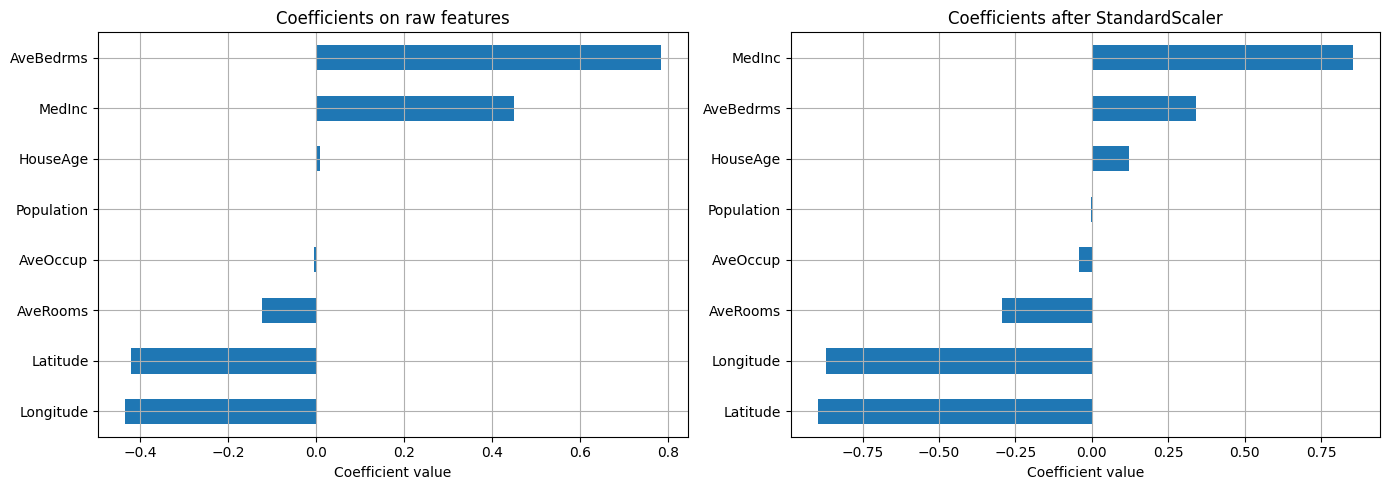

In [42]:
coef_plot = coef_compare.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

coef_plot["coefficient_raw_units"].sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Coefficients on raw features")
axes[0].set_xlabel("Coefficient value")

coef_plot["coefficient_standardized_units"].sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Coefficients after StandardScaler")
axes[1].set_xlabel("Coefficient value")

plt.tight_layout()
plt.show()

### Optimization sensitivity: SGD with and without scaling

In [46]:
sgd_raw = Pipeline([
    ("model", SGDRegressor(
        loss="squared_error",
        penalty=None,
        max_iter=2000,
        tol=0.01,
        random_state=42
    ))
])

sgd_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SGDRegressor(
        loss="squared_error",
        penalty=None,
        max_iter=2000,
        tol=0.01,
        random_state=42
    ))
])

sgd_raw_res, sgd_raw_test_pred = evaluate_regression(
    sgd_raw, X_train, X_test, y_train, y_test, name="SGDRegressor_raw"
)

sgd_scaled_res, sgd_scaled_test_pred = evaluate_regression(
    sgd_scaled, X_train, X_test, y_train, y_test, name="SGDRegressor_scaled"
)

sgd_results = pd.concat(
    [sgd_raw_res, sgd_scaled_res],
    ignore_index=True
)

sgd_results

,model,split,MAE,RMSE,R2
0,SGDRegressor_raw,train,1.820310e+14,2.097508e+14,-3.291151e+28
1,SGDRegressor_raw,test,1.815199e+14,2.082551e+14,-3.309669e+28
2,SGDRegressor_scaled,train,5.274808e-01,7.270569e-01,6.045629e-01
3,SGDRegressor_scaled,test,5.298786e-01,7.420293e-01,5.798201e-01


### Interpretation

Typical outcome:

- **LinearRegression_raw** and **LinearRegression_scaled** should have nearly identical predictions
- their **coefficients are not directly comparable**, because the feature units differ
- **SGDRegressor_scaled** is often more stable and reaches a better solution than `SGDRegressor_raw`

This is a good teaching example:

- scaling is not always about improving final accuracy
- scaling is often about making optimization and coefficient interpretation easier

## 15. Residual analysis

Residuals can reveal bias, non-linearity, and heteroscedasticity.


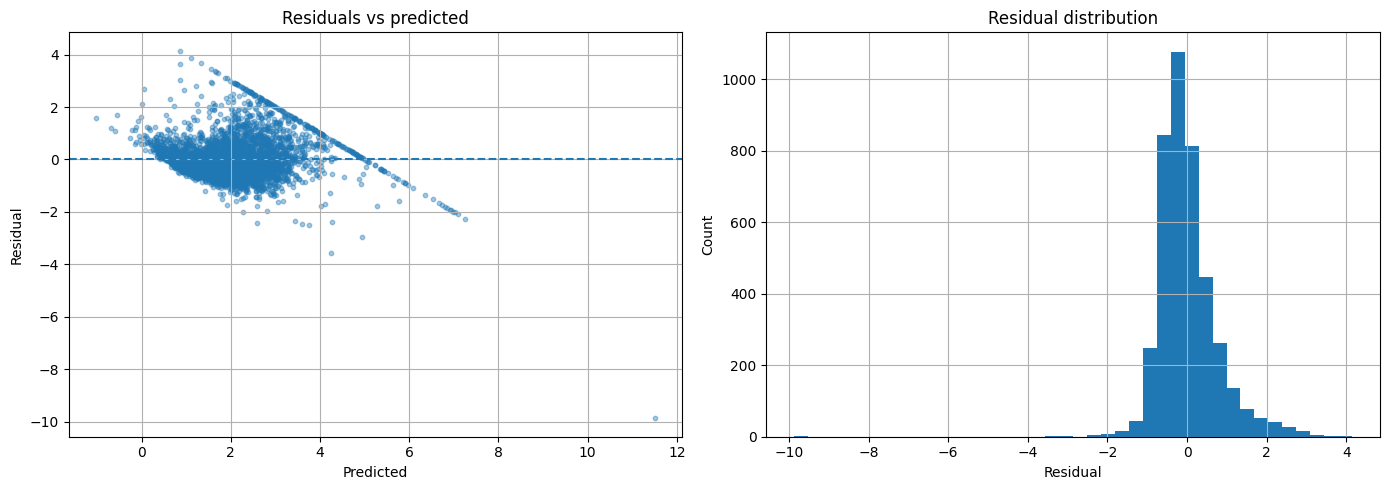

In [47]:
residuals = y_test - all_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(all_pred, residuals, s=10, alpha=0.4)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Residuals vs predicted")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual")

axes[1].hist(residuals, bins=40)
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## 17. Non-linear benchmark: Random Forest

This is useful pedagogically: the dataset contains non-linear structure, so a tree-based model often performs much better than a linear model.


In [48]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

rf_results, rf_pred = evaluate_regression(
    rf, X_train, X_test, y_train, y_test, name="RandomForestRegressor"
)
rf_results


,model,split,MAE,RMSE,R2
0,RandomForestRegressor,train,0.144075,0.234463,0.958876
1,RandomForestRegressor,test,0.325997,0.504018,0.806141


## 18. Compare all models

In [ ]:
results = pd.concat(
    [baseline_results, single_results, all_results, ridge_results, rf_results],
    ignore_index=True,
)

results.sort_values(["split", "RMSE"])


In [ ]:
test_results = results[results["split"] == "test"].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(test_results["model"], test_results["MAE"])
axes[0].set_title("Test MAE")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(test_results["model"], test_results["RMSE"])
axes[1].set_title("Test RMSE")
axes[1].tick_params(axis="x", rotation=25)

axes[2].bar(test_results["model"], test_results["R2"])
axes[2].set_title("Test R²")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


## 19. Actual vs predicted comparison



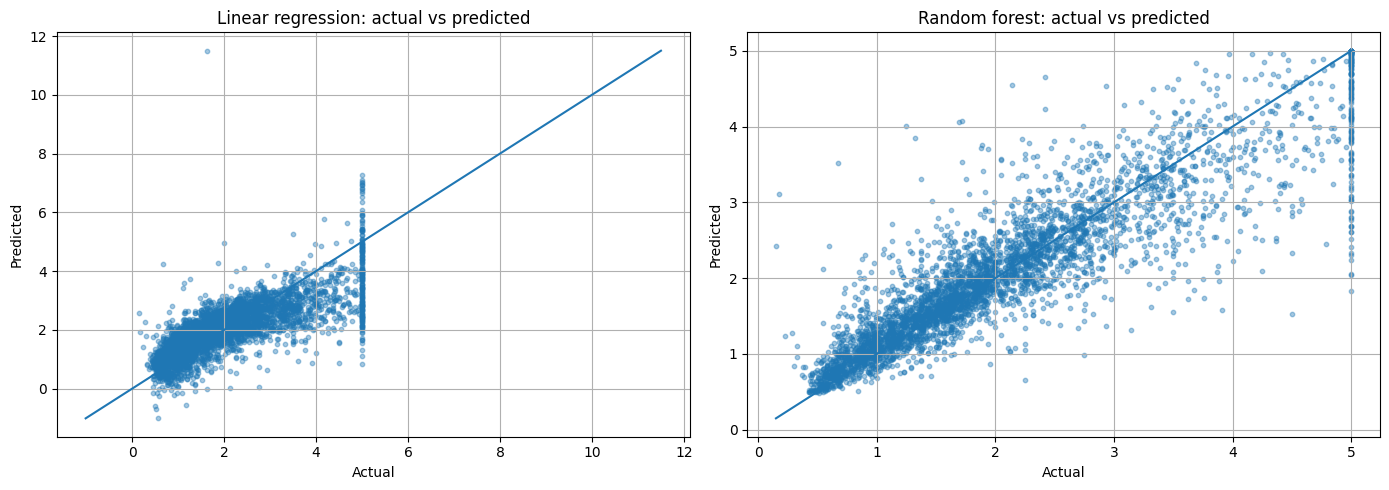

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, all_pred, s=10, alpha=0.4)
mn = min(y_test.min(), all_pred.min())
mx = max(y_test.max(), all_pred.max())
axes[0].plot([mn, mx], [mn, mx])
axes[0].set_title("Linear regression: actual vs predicted")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

axes[1].scatter(y_test, rf_pred, s=10, alpha=0.4)
mn = min(y_test.min(), rf_pred.min())
mx = max(y_test.max(), rf_pred.max())
axes[1].plot([mn, mx], [mn, mx])
axes[1].set_title("Random forest: actual vs predicted")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()


## 20. Main observations

Typical observations from this notebook:
1. **Median income** is one of the strongest predictors.
2. **Location** matters a lot; latitude and longitude capture major geographic effects.
3. A **single-feature** linear model is useful for intuition but leaves a lot of error.
4. A **multivariable** linear model is clearly better.
5. A **non-linear** model usually wins because the price patterns are not purely linear.



## 21. Descision Trees

In [98]:
# a perfect training score (R² = 1.0) using an unconstrained `DecisionTreeRegressor` — 
# this is the classic overfitting demonstration:

# With no `max_depth` set, the tree grows until every leaf contains exactly one training sample — 
# it memorizes the data perfectly. Train R² = 1.000, but test R² collapses to ~0.62, 
# illustrating the point: *"perfect train score ≠ good test score."*


from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

# Load data
housing = fetch_california_housing()
X, y = housing.data, housing.target

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Unconstrained tree — no max_depth limit
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

# Scores
print(f"Train R²: {tree.score(X_train, y_train):.3f}")  # → 1.000
print(f"Test  R²: {tree.score(X_test,  y_test):.3f}")   # → ~0.62


Train R²: 1.000
Test  R²: 0.622


In [95]:
# Constrained tree — prevents overfitting
# The shallow tree trades a little training accuracy for much better generalization —
#  which sets up the hyperparameter tuning slide perfectly.

tree_shallow = DecisionTreeRegressor(max_depth=11, random_state=42, min_samples_leaf=10, min_samples_split=20)
tree_shallow.fit(X_train, y_train)

print(f"Shallow Train R²: {tree_shallow.score(X_train, y_train):.3f}")  
print(f"Shallow Test  R²: {tree_shallow.score(X_test,  y_test):.3f}")   



Shallow Train R²: 0.824
Shallow Test  R²: 0.722


In [99]:
# Basic summary of the unconstrained tree trained above
print("Decision tree summary")
print("- max_depth in model params:", tree.get_params()["max_depth"])
print("- actual tree depth:", tree.get_depth())
print("- number of nodes:", tree.tree_.node_count)
print("- number of leaves:", tree.get_n_leaves())
print("- number of features used for training:", X_train.shape[1])
print("- training samples:", X_train.shape[0])
print("- test samples:", X_test.shape[0])
print("- train MSE:", round(mean_squared_error(y_train, tree.predict(X_train)), 4))
print("- test MSE:", round(mean_squared_error(y_test, tree.predict(X_test)), 4))


Decision tree summary
- max_depth in model params: None
- actual tree depth: 34
- number of nodes: 31707
- number of leaves: 15854
- number of features used for training: 8
- training samples: 16512
- test samples: 4128
- train MSE: 0.0
- test MSE: 0.4952


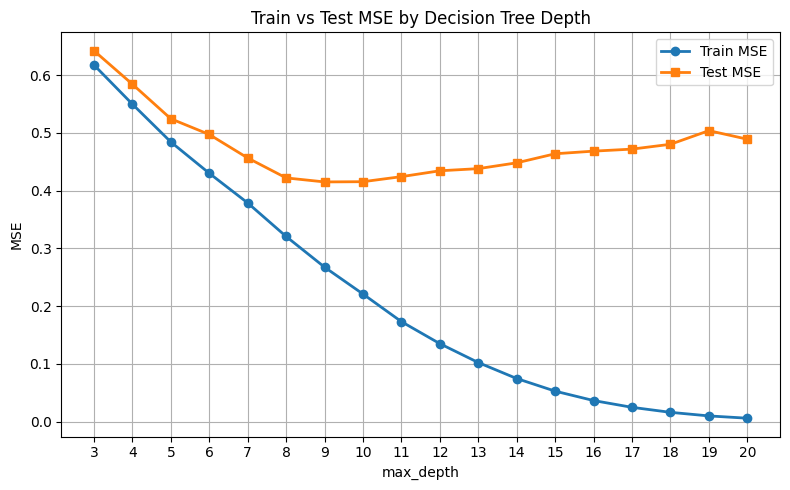

In [100]:
depths = list(range(3, 21))
train_mse_scores = []
test_mse_scores = []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_mse_scores.append(mean_squared_error(y_train, y_train_pred))
    test_mse_scores.append(mean_squared_error(y_test, y_test_pred))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths, train_mse_scores, marker="o", linewidth=2, label="Train MSE")
ax.plot(depths, test_mse_scores, marker="s", linewidth=2, label="Test MSE")
ax.set_title("Train vs Test MSE by Decision Tree Depth")
ax.set_xlabel("max_depth")
ax.set_ylabel("MSE")
ax.set_xticks(depths)
ax.legend()
plt.tight_layout()
plt.show()
